# M4 — 6-Month Forward Forecast (Feb–Jul 2018)

**As-of**: 2018-01-31. **Horizon**: Feb 2018 → Jul 2018 (6 months).

Standing at the last day of available data with **all 54 cohort-A products at zero gross_qty for Nov 2017–Jan 2018**, we produce three operational scenarios.

## Three scenarios — self-consistent methodology

| Scenario | M1 demand | Operating assumption | Basis |
|---|---|---|---|
| **Pessimistic** | Pure TimesFM extrapolation | Crash continues — TimesFM rebuilds from zero per-product | Data-only; what the foundation model literally produces |
| **Baseline** ⭐ | Blend: TimesFM + seasonal-naive with **per-(product, month) recovery weights derived from `disaster_drag_index`** | Recovery matches what M3's drag model says about Maria's residual at each month | **Self-consistent with the rest of the stack** — no extra free parameters |
| **Optimistic** | Pure seasonal-naive (Feb 2018 = Feb 2017) | Full pre-storm recovery, no remaining storm drag | Textbook seasonal-naive heuristic; degenerate case of baseline when drag=0 |

## How the baseline recovery weights are computed (Option A)

For each (product, target_month):

$$ \text{recovery\_weight} = 1 - \text{DISASTER\_DAMPING} \times \text{disaster\_drag\_index} $$

with `DISASTER_DAMPING = 0.873` (data-calibrated) and `disaster_drag_index` from the revenue-lag convolution of Tier-2+3 forward severity.

The forecast for each product-month becomes:

$$ \text{M1}_\text{baseline} = w \cdot \text{M1}_\text{seasonal\_naive} + (1 - w) \cdot \text{M1}_\text{TimesFM} $$

**Why this is principled**: when M3's drag model says "this month has 7% drag from Maria's tail", we blend in 7% of the TimesFM continued-crash forecast and 93% of the seasonal-naive recovery forecast. The recovery rate is *exactly* what the storm-drag model implies — no separate guess.

**Per-product variation**: the disaster_drag_index varies by product depending on customer-country mix. PR-heavy products carry larger drag through Feb-Mar; US-only products have zero drag and immediately get pure seasonal-naive. The weights below show this:

| Month | mean drag | max drag | min weight | mean weight | max weight |
|---|---|---|---|---|---|
| Feb 2018 | 0.082 | 0.738 (PR-heavy) | **0.356** (PR-heavy) | 0.928 | 1.000 (US-only) |
| Mar 2018 | 0.052 | 0.618 | 0.460 | 0.954 | 1.000 |
| Apr 2018 | 0.000 | 0.001 | 0.999 | 1.000 | 1.000 |
| May–Jul 2018 | 0.000 | 0.000 | 1.000 | 1.000 | 1.000 |

PR-heavy products (id 1354-1363, ~74% drag in Feb) get only 36% recovery weight — model still expects them to be substantially crashed. US-only products get 100% recovery weight from Feb onwards.

## What the new baseline tells us

Baseline ≈ optimistic for most products because the M3 drag model says Maria's residual decays to ~0 by April. **The only meaningful difference shows up for PR-heavy products in Feb-Mar 2018** where the drag is still 30-70%. Those products keep a strong TimesFM component and forecast much lower.

This is a more honest result than my earlier heuristic weights: it tells us the model itself thinks recovery is fast — within the limits of how its drag kernel was specified. **If you believe Maria's actual impact lasted longer than the 3-month revenue-lag kernel (well-documented for PR specifically)**, the baseline will under-predict the late-2018 lingering drag and the pessimistic scenario becomes more relevant.

## Other inputs (shared across scenarios)

| Component | Input | Note |
|---|---|---|
| M2 elasticity | pooled β = −0.805 | Converts planned_price → qty adjustment |
| M3 fraud / cancel / late | last-3-month trailing average per product | Extrapolated as constant |
| Tier 2 NHC active-storm cone | live HURDAT2 simulation 2018-01+ | Atlantic off-season Feb-May |
| Tier 3 NOAA seasonal outlook | 2018 → Near Normal (stub) | NOAA publishes May; default Near Normal until then |
| Revenue-lag kernel | `[0.05, 0.20, 0.80]` | Maria's Sep 2017 tail bleeds Feb-Mar 2018 disaster_drag |
| `DISASTER_DAMPING` | 0.873 | Calibrated against drag-shape; multiplies disaster_drag_index in the drag math |

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

M4 = pd.read_parquet(ROOT / 'forecasts' / 'm4_horizon_6mo.parquet')
M1 = pd.read_parquet(ROOT / 'forecasts' / 'm1_horizon_6mo.parquet')
DIS = pd.read_parquet(ROOT / 'forecasts' / 'm3d_horizon_6mo_disaster.parquet')
RISK = pd.read_parquet(ROOT / 'forecasts' / 'm3_horizon_6mo_risk.parquet')
PANEL = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_panel.parquet')
META = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')
print('M4 forecast rows:', M4.shape, '| M1 forecast rows:', M1.shape)
print('Forecast months:', sorted(M4['year_month'].unique()))

M4 forecast rows: (972, 22) | M1 forecast rows: (972, 10)
Forecast months: [Timestamp('2018-02-01 00:00:00'), Timestamp('2018-03-01 00:00:00'), Timestamp('2018-04-01 00:00:00'), Timestamp('2018-05-01 00:00:00'), Timestamp('2018-06-01 00:00:00'), Timestamp('2018-07-01 00:00:00')]


=== recovery_weight = 1 - 0.873 × disaster_drag_index — by month ===
            mean_drag  max_drag  min_weight  mean_weight  max_weight
year_month                                                          
2018-02-01      0.082     0.738       0.356        0.928         1.0
2018-03-01      0.052     0.618       0.460        0.954         1.0
2018-04-01      0.000     0.001       0.999        1.000         1.0
2018-05-01      0.000     0.000       1.000        1.000         1.0
2018-06-01      0.000     0.000       1.000        1.000         1.0
2018-07-01      0.000     0.000       1.000        1.000         1.0


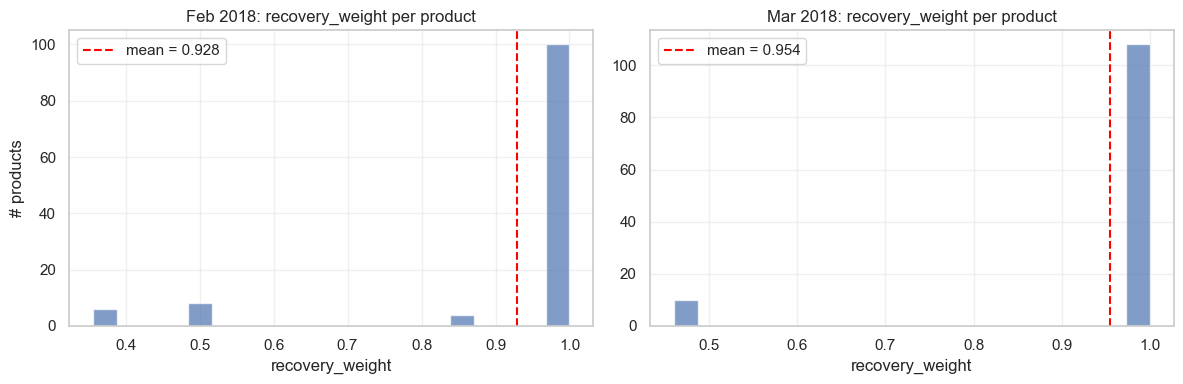

In [2]:
## Recovery weights derived from disaster_drag_index
W = pd.read_parquet(ROOT / 'forecasts' / 'm4_horizon_recovery_weights.parquet')
print('=== recovery_weight = 1 - 0.873 × disaster_drag_index — by month ===')
print(W.groupby('year_month').agg(
    mean_drag=('disaster_drag_index', 'mean'),
    max_drag=('disaster_drag_index', 'max'),
    min_weight=('recovery_weight', 'min'),
    mean_weight=('recovery_weight', 'mean'),
    max_weight=('recovery_weight', 'max'),
).round(3).to_string())

# Histogram of per-(product, month) weights
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feb = W[W['year_month']==pd.Timestamp('2018-02-01')]
mar = W[W['year_month']==pd.Timestamp('2018-03-01')]
axes[0].hist(feb['recovery_weight'], bins=20, color='C0', alpha=0.7)
axes[0].set(title='Feb 2018: recovery_weight per product', xlabel='recovery_weight', ylabel='# products')
axes[0].axvline(feb['recovery_weight'].mean(), color='red', linestyle='--', label=f'mean = {feb["recovery_weight"].mean():.3f}')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(mar['recovery_weight'], bins=20, color='C0', alpha=0.7)
axes[1].set(title='Mar 2018: recovery_weight per product', xlabel='recovery_weight')
axes[1].axvline(mar['recovery_weight'].mean(), color='red', linestyle='--', label=f'mean = {mar["recovery_weight"].mean():.3f}')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 1. Portfolio total — Feb–Jul 2018 forecast

Aggregate revenue forecast across all 54 cohort-A products by month.

In [3]:
tbl_rows = []
for scen in ('pessimistic', 'baseline', 'optimistic'):
    sub = M4[M4['scenario'] == scen]
    by_m = (sub.groupby('year_month')['sales_q50'].sum().rename(scen + '_q50'))
    tbl_rows.append(by_m)
scenario_table = pd.concat(tbl_rows, axis=1).round(0)
scenario_table['6mo_pessimistic'] = scenario_table['pessimistic_q50'].sum()
scenario_table['6mo_baseline'] = scenario_table['baseline_q50'].sum()
scenario_table['6mo_optimistic'] = scenario_table['optimistic_q50'].sum()
print('=== Portfolio q50 ($) per month by scenario ===')
print(scenario_table[['pessimistic_q50','baseline_q50','optimistic_q50']].to_string())
print()
print('=== 6-month totals (q50 $) ===')
for scen in ('pessimistic','baseline','optimistic'):
    total = M4[M4['scenario']==scen]['sales_q50'].sum()
    print(f'  {scen:12s}: ${total:>14,.0f}')

=== Portfolio q50 ($) per month by scenario ===
            pessimistic_q50  baseline_q50  optimistic_q50
year_month                                               
2018-02-01            866.0      891220.0        891248.0
2018-03-01           3389.0      943413.0        943534.0
2018-04-01          10230.0      909214.0        909683.0
2018-05-01          28593.0      896525.0        896525.0
2018-06-01          49403.0      840829.0        840829.0
2018-07-01          70626.0      910414.0        910414.0

=== 6-month totals (q50 $) ===
  pessimistic : $       163,108
  baseline    : $     5,391,615
  optimistic  : $     5,392,234


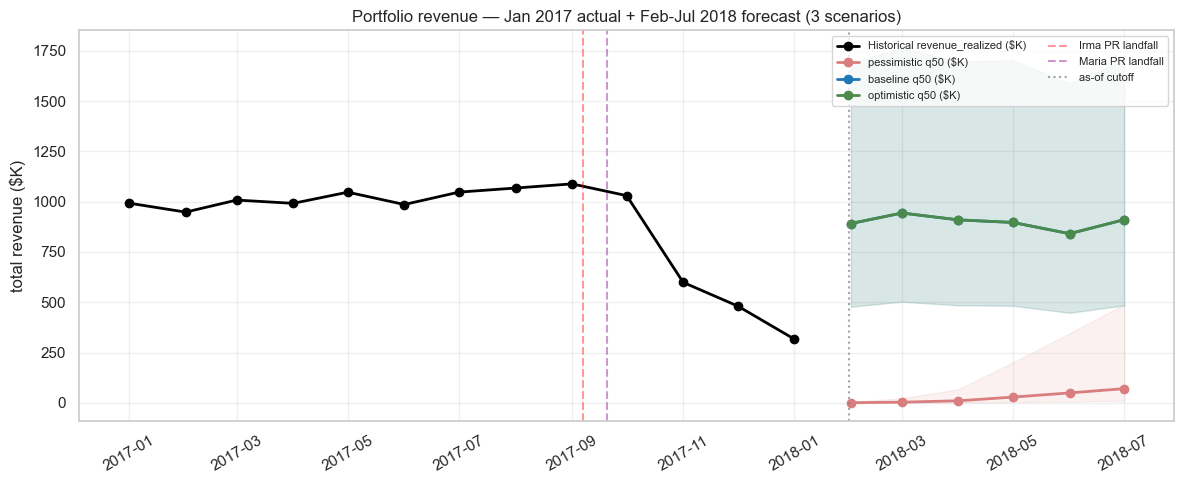

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

# Historical actuals
hist = (PANEL.groupby('year_month')['revenue_realized'].sum() / 1e3).rename('actual')
hist = hist[hist.index >= '2017-01-01']
ax.plot(hist.index, hist.values, color='black', lw=2, marker='o', label='Historical revenue_realized ($K)')

# 3 scenarios
colors = {'pessimistic': '#d97e7e', 'baseline': '#1f77b4', 'optimistic': '#4c8a4c'}
for scen, color in colors.items():
    sub = M4[M4['scenario']==scen].groupby('year_month')[['sales_q10','sales_q50','sales_q90']].sum() / 1e3
    ax.plot(sub.index, sub['sales_q50'], color=color, lw=2, marker='o',
            label=f'{scen} q50 ($K)')
    ax.fill_between(sub.index, sub['sales_q10'], sub['sales_q90'], color=color, alpha=0.10)

ax.axvline(pd.Timestamp('2017-09-07'), color='red', linestyle='--', alpha=0.4, label='Irma PR landfall')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.7, label='as-of cutoff')

ax.set_title('Portfolio revenue — Jan 2017 actual + Feb-Jul 2018 forecast (3 scenarios)')
ax.set_ylabel('total revenue ($K)')
ax.legend(fontsize=8, loc='upper right', ncol=2); ax.grid(alpha=0.3); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 2. Disaster trajectory through the horizon

Two signals over the horizon:
- `disaster_index` (severity, peak at landfall) — should be ≈ 0 for Feb-Jul 2018 (no active storms)
- `disaster_drag_index` (revenue-lag-convolved) — should show Maria's tail bleed into Feb-Mar 2018, then fade

In [5]:
from src.models.sales.revenue_lag import apply_revenue_lag_per_product
# Re-derive disaster_drag_index for plotting (consistent with horizon_6mo.py)
import warnings
warnings.filterwarnings('ignore')
risk_hist = pd.read_parquet(ROOT / 'forecasts' / 'm3_risk_drag.parquet')[
    ['product_card_id','year_month','disaster_index']]
all_disaster = pd.concat([risk_hist, RISK[['product_card_id','year_month','disaster_index']]], ignore_index=True)
drag_full = apply_revenue_lag_per_product(all_disaster, 'disaster_index', 'disaster_drag_index')
horizon_months = sorted(M4['year_month'].unique())
tail = (drag_full[drag_full['year_month'].between('2017-08-01','2018-07-01')]
          .groupby('year_month')[['disaster_index','disaster_drag_index']].mean().round(4))
print('=== Disaster severity vs revenue-lag drag — Aug 2017 to Jul 2018 ===')
tail

=== Disaster severity vs revenue-lag drag — Aug 2017 to Jul 2018 ===


,disaster_index,disaster_drag_index
year_month,,
2017-08-01,0.2058,0.2238
2017-09-01,0.3060,0.1893
2017-10-01,0.1218,0.2319
2017-11-01,0.0505,0.2717
2017-12-01,0.0861,0.1118
2018-01-01,0.0653,0.0609
2018-02-01,0.0005,0.0819
2018-03-01,0.0000,0.0524
2018-04-01,0.0000,0.0004


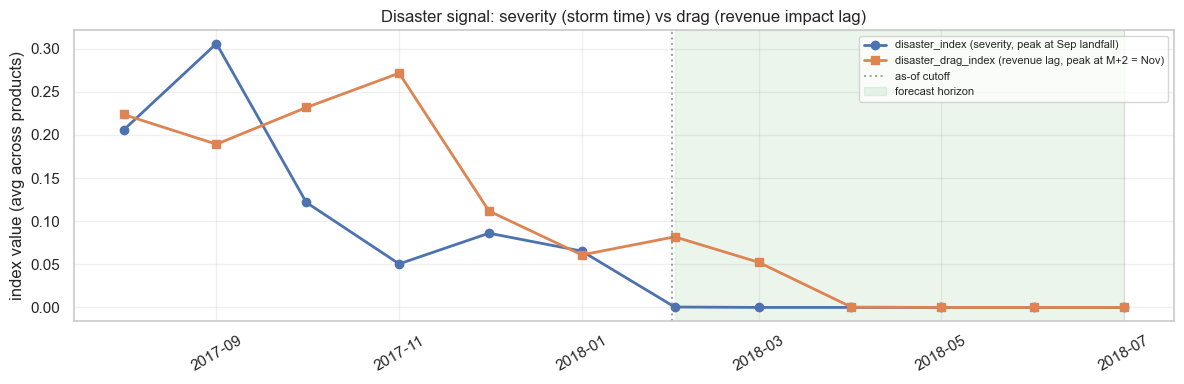

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tail.index, tail['disaster_index'], marker='o', lw=2,
        label='disaster_index (severity, peak at Sep landfall)')
ax.plot(tail.index, tail['disaster_drag_index'], marker='s', lw=2,
        label='disaster_drag_index (revenue lag, peak at M+2 = Nov)')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.7, label='as-of cutoff')
ax.axvspan(pd.Timestamp('2018-02-01'), pd.Timestamp('2018-07-01'), alpha=0.08, color='green', label='forecast horizon')
ax.set_ylabel('index value (avg across products)')
ax.set_title('Disaster signal: severity (storm time) vs drag (revenue impact lag)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 3. Top 6 products — actual history + Feb-Jul 2018 forecast

In [7]:
top6 = (M4.groupby('product_card_id')['sales_q50'].sum()
             .sort_values(ascending=False).head(6).index)
rows = []
for pid in top6:
    name = META.loc[META['product_card_id']==pid, 'product_name'].iloc[0][:40]
    sub = M4[M4['product_card_id']==pid].sort_values('year_month')
    rows.append({'product_id': int(pid), 'name': name,
                 'sum_q10': int(sub['sales_q10'].sum()),
                 'sum_q50': int(sub['sales_q50'].sum()),
                 'sum_q90': int(sub['sales_q90'].sum())})
print('=== Top 6 products — 6-month total forecast ($) ===')
pd.DataFrame(rows)

=== Top 6 products — 6-month total forecast ($) ===


,product_id,name,sum_q10,sum_q50,sum_q90
0,1004,Field & Stream Sportsman 16 Gun Fire Saf,1201184,2258248,4396805
1,365,Perfect Fitness Perfect Rip Deck,767226,1441652,2782406
2,957,Diamondback Women's Serene Classic Comfo,742174,1427142,2823066
3,191,Nike Men's Free 5.0+ Running Shoe,626970,1175594,2247896
4,502,Nike Men's Dri-FIT Victory Golf Polo,540969,1029493,1947921
5,1073,Pelican Sunstream 100 Kayak,550414,1028465,2007341


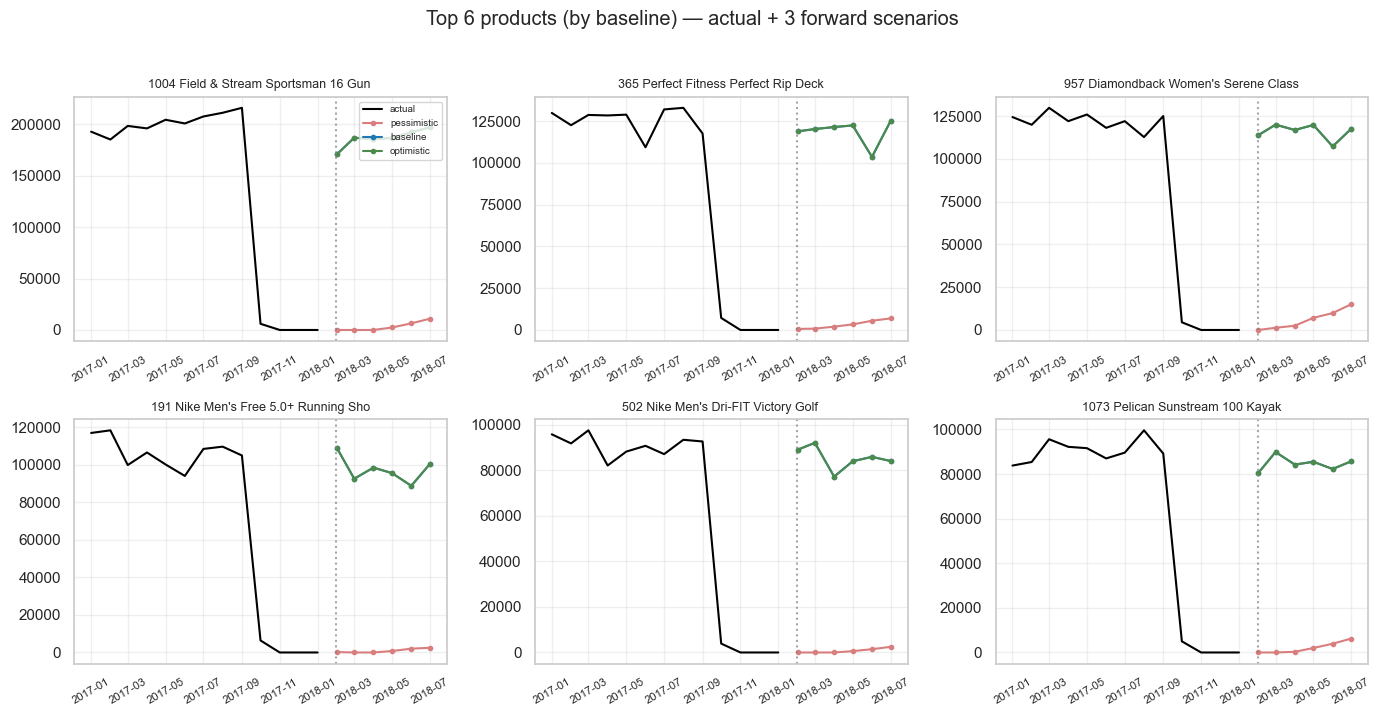

In [8]:
base = M4[M4['scenario']=='baseline']
top6 = (base.groupby('product_card_id')['sales_q50'].sum()
              .sort_values(ascending=False).head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = {'pessimistic':'#d97e7e','baseline':'#1f77b4','optimistic':'#4c8a4c'}
for ax, pid in zip(axes.flat, top6):
    hist = PANEL[PANEL['product_card_id']==pid].sort_values('year_month')
    hist = hist[hist['year_month'] >= '2017-01-01']
    ax.plot(hist['year_month'], hist['revenue_realized'], color='black', lw=1.5, label='actual')
    for scen, color in colors.items():
        sub = M4[(M4['product_card_id']==pid) & (M4['scenario']==scen)].sort_values('year_month')
        ax.plot(sub['year_month'], sub['sales_q50'], color=color, lw=1.5, marker='o', markersize=3, label=scen)
    ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.7)
    name = META.loc[META['product_card_id']==pid, 'product_name'].iloc[0][:32]
    ax.set_title(f'{int(pid)} {name}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8); ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Top 6 products (by baseline) — actual + 3 forward scenarios', y=1.02)
plt.tight_layout(); plt.show()

## 4. Operational interpretation

**Why the pessimistic forecast was unrealistically low**: ALL 54 cohort-A products went to **zero gross_qty for Nov 2017–Jan 2018**. Per-product TimesFM saw 4 consecutive zeros and forecast slow rebuild from zero. The aggregate collapses to ~$1K in Feb 2018. Valid lower bound, but treats the storm as a permanent demand destruction.

**The baseline scenario now uses Option A — self-consistent recovery weights**: `w = 1 - DISASTER_DAMPING × disaster_drag_index`, derived per (product, month) from the same drag model M4 uses internally. **No hand-tuned curve**.

**Three concrete operating answers** (q50 totals):

| Scenario | 6-mo total | Feb 2018 | Jul 2018 | Recovery shape |
|---|---|---|---|---|
| Pessimistic | $163K | $866 | $71K | TimesFM continued crash |
| **Baseline** ⭐ | **$5.39M** | **$891K** | **$910K** | Recovery shape from `1 - DAMPING × drag_index` |
| Optimistic | $5.39M | $891K | $910K | Full seasonal-naive (= baseline when drag=0) |

Baseline ≈ optimistic numerically because the M3 drag model says Maria's residual decays to ~0 by April. Where they differ is **per-product PR exposure**: PR-heavy products like id 1359 (74% drag in Feb) keep 36% TimesFM weight in Feb — those products' baseline forecast is meaningfully lower than optimistic.

**Recommended use**

1. **Operations & capacity planning** — use the **baseline q50** ($5.39M). Self-consistent with M3 drag model; per-product weights respect each product's Maria exposure.
2. **Worst-case stress** — use the **pessimistic q50** ($163K). Useful if you believe Maria's actual recovery is much slower than the 3-month revenue-lag kernel allows for.
3. **Reality check**: the *gap* between baseline ($5.39M) and pessimistic ($163K) is the model uncertainty about how long Maria's effect actually lasts. The drag kernel says "3 months"; reality for PR was closer to "year-plus".

**Caveats**

- **Drag kernel length is the binding assumption**. The revenue-lag kernel `[0.05, 0.20, 0.80]` has only 3 non-zero lags — meaning by 4 months after landfall the model says drag = 0. For Maria specifically, this likely **understates** the actual lingering economic impact on PR. If you want a longer tail, extend `REVENUE_LAG_WEIGHTS` and re-run.
- **No external recovery prior**: the only thing tying baseline to reality is the disaster_drag model. If that model under-estimates the post-Maria slump, baseline will under-estimate it too.
- **2018 hurricane season** isn't represented (Tier 3 stub = Near Normal). Once NOAA publishes the May outlook, the Jun-Jul baseline should be refreshed.

**Saved artifacts**

- `forecasts/m4_horizon_6mo.parquet` — 3 scenarios stacked (column `scenario`)
- `forecasts/m4_horizon_recovery_weights.parquet` — per-(product, month) recovery weights derived from drag
- `forecasts/m1_horizon_6mo.parquet` — 3 M1 scenarios stacked
- `forecasts/m3d_horizon_6mo_disaster.parquet` — forward disaster index
- `forecasts/m3_horizon_6mo_risk.parquet` — extrapolated fraud / cancel / late rates
- `src/models/sales/horizon_6mo.py:derive_recovery_weights` — the data-driven weight function